# Unipolar PAM-4 IM/DD — End-to-End Autoencoder

Eye diagram and BER vs $E_b/N_0$ for the 4-segment-MZM + dispersive-fiber link
(DPD at the transmitter, FFE at the receiver, trained jointly).

**Just run all cells.** If a trained checkpoint (`results/pam4_baseline.pt`) exists it is
loaded; otherwise the autoencoder is trained from scratch and saved. To force a retrain
(e.g. after editing `config.py`), set `FORCE_RETRAIN = True` below or delete the checkpoint.

Run this notebook from the `MLforCPO2` folder so the local modules and `results/` path resolve.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import resample_poly

from config import Config
from channel import OpticalChannel
from transmitter import Transmitter, bits_to_symbols
from receiver import Receiver
from train import train, evaluate, random_bits
from utils import theoretical_ber_unipolar, decision_phase_by_separation

%matplotlib inline

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ----- knobs -----
CHECKPOINT = os.path.join("results", "pam4_baseline.pt")
NUM_STEPS = 10000        # training steps when no checkpoint is found
NUM_EVAL = 400000        # symbols per Eb/N0 point in the waterfall
FORCE_RETRAIN = False    # set True to ignore an existing checkpoint and retrain

config = Config()
config.minibatch_symbols = 4096
config.edge_guard_symbols = 48
print(config.summary())

device: cuda
symbol rate          : 20 GBaud
bit rate             : 40 Gb/s  (PAM-4)
sim sample rate      : 80 GHz  (4 sps, Nyquist 40 GHz)
rx sample rate       : 40 GHz  (2 sps)
MZM bandwidth        : 30 GHz  (representable: True)
photodiode bandwidth : 25 GHz  (representable: True)
MZM segments         : 4
pulse shape          : RRC roll-off 0.85


## Load the trained autoencoder (or train it if missing)

In [2]:
def load_or_train(config, device, num_steps, checkpoint_path, num_eval, force_retrain=False):
    """Return tx, channel, rx, ebn0_db, measured — loading a checkpoint if present."""
    transmitter = Transmitter(config).to(device)
    channel = OpticalChannel(config).to(device)
    receiver = Receiver(config).to(device)

    if os.path.exists(checkpoint_path) and not force_retrain:
        print(f"loading checkpoint: {checkpoint_path}")
        ckpt = torch.load(checkpoint_path, weights_only=False, map_location=device)
        transmitter.load_state_dict(ckpt["transmitter"])
        receiver.load_state_dict(ckpt["receiver"])
        ebn0_db = np.asarray(ckpt["ebn0_db"])
        measured = np.asarray(ckpt["measured"])
    else:
        print("no checkpoint (or FORCE_RETRAIN) -> training from scratch")
        torch.manual_seed(0)
        np.random.seed(0)
        transmitter, channel, receiver = train(config, device, num_steps=num_steps)
        ebn0_db = np.arange(6, 22, 2.0)
        measured = evaluate(transmitter, channel, receiver, config, ebn0_db, num_eval, device)
        os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
        torch.save({
            "transmitter": transmitter.state_dict(),
            "receiver": receiver.state_dict(),
            "config": {k: v for k, v in vars(config).items()},
            "ebn0_db": ebn0_db,
            "measured": measured,
        }, checkpoint_path)
        print(f"saved checkpoint: {checkpoint_path}")

    transmitter.eval()
    receiver.eval()
    return transmitter, channel, receiver, ebn0_db, measured


transmitter, channel, receiver, ebn0_db, measured = load_or_train(
    config, device, NUM_STEPS, CHECKPOINT, NUM_EVAL, FORCE_RETRAIN)

no checkpoint (or FORCE_RETRAIN) -> training from scratch
=== joint training (DPD + FFE together, noise + equispacing) ===
  step    0  ebn0 13.6  bce 0.6968  level 1.1250  BER 0.5010
  step 1250  ebn0 16.5  bce 0.5588  level 0.0058  BER 0.2990
  step 2500  ebn0 17.2  bce 0.1061  level 0.0047  BER 0.0028
  step 3750  ebn0 17.7  bce 0.0373  level 0.0052  BER 0.0004
  step 5000  ebn0 11.4  bce 0.0816  level 0.0052  BER 0.0287
  step 6250  ebn0 16.3  bce 0.0198  level 0.0045  BER 0.0004
  step 7500  ebn0 13.1  bce 0.0423  level 0.0048  BER 0.0125
  step 8750  ebn0  9.3  bce 0.1475  level 0.0047  BER 0.0594
  step 9999  ebn0 16.8  bce 0.0139  level 0.0044  BER 0.0007
Eb/N0   6.0 dB   BER 1.224e-01   (shift 0)
Eb/N0   8.0 dB   BER 8.088e-02   (shift 0)
Eb/N0  10.0 dB   BER 4.536e-02   (shift 0)
Eb/N0  12.0 dB   BER 1.985e-02   (shift 0)
Eb/N0  14.0 dB   BER 5.988e-03   (shift 0)
Eb/N0  16.0 dB   BER 1.120e-03   (shift 0)
Eb/N0  18.0 dB   BER 7.002e-05   (shift 0)
Eb/N0  20.0 dB   BER 1.250e

## Eye diagram (photodetected, noiseless)

level means (sym 0..3): [-0.0088  0.1411  0.4514  0.2994]
sorted gaps: [0.1499 0.1583 0.1519]   equispacing std/mean = 0.024


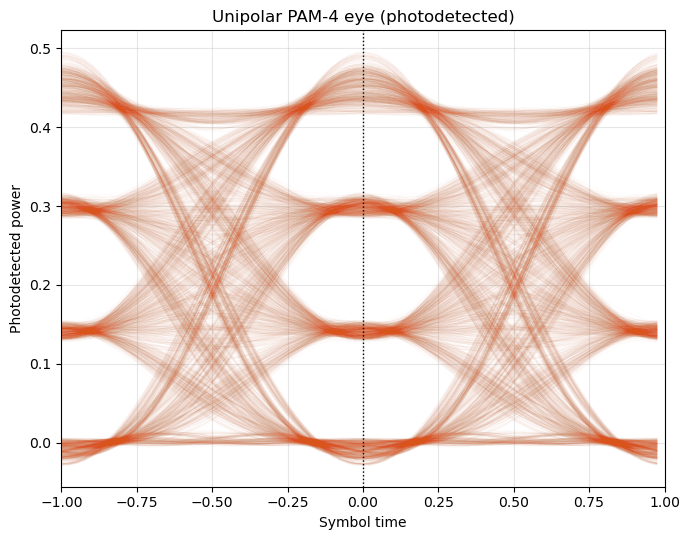

In [3]:
def draw_eye(ax, photocurrent, samples_per_symbol, phase, title,
             fine_sps=40, skip=100, num_symbols=4000):
    fine = resample_poly(photocurrent[:(skip + num_symbols + 8) * samples_per_symbol],
                         fine_sps, samples_per_symbol)
    offset = int(round(phase * fine_sps / samples_per_symbol))
    centers = (skip + np.arange(num_symbols)) * fine_sps + offset
    keep = (centers - fine_sps >= 0) & (centers + fine_sps < len(fine))
    centers = centers[keep]
    window = np.arange(-fine_sps, fine_sps)[:, None] + centers[None, :]
    ax.plot(np.arange(-fine_sps, fine_sps) / fine_sps, fine[window],
            color=(0.85, 0.33, 0.10, 0.03), linewidth=0.4)
    ax.axvline(0, color="k", linestyle=":", linewidth=1)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Symbol time")
    ax.set_ylabel("Photodetected power")
    ax.set_title(title)


sps = config.samples_per_symbol_sim
with torch.no_grad():
    bits = random_bits(config.bits_per_symbol, 6000, device)
    symbols = bits_to_symbols(bits, config.bits_per_symbol).cpu().numpy()
    photocurrent = channel(transmitter(bits), add_noise=False).cpu().numpy()

phase, levels = decision_phase_by_separation(photocurrent, sps, symbols)
gaps = np.diff(np.sort(levels))
print(f"level means (sym 0..3): {np.round(levels, 4)}")
print(f"sorted gaps: {np.round(gaps, 4)}   equispacing std/mean = {gaps.std() / gaps.mean():.3f}")

fig_eye, ax_eye = plt.subplots(figsize=(7, 5.5))
draw_eye(ax_eye, photocurrent, sps, phase, "Unipolar PAM-4 eye (photodetected)")
fig_eye.tight_layout()
fig_eye.savefig(os.path.join("results", "pam4_eye.png"), dpi=150, bbox_inches="tight")
plt.show()

## BER vs $E_b/N_0$ curves

  Eb/N0     measured     theory
    6.0    1.224e-01    1.073e-01
    8.0    8.088e-02    6.727e-02
   10.0    4.536e-02    3.411e-02
   12.0    1.985e-02    1.250e-02
   14.0    5.988e-03    2.769e-03
   16.0    1.120e-03    2.792e-04
   18.0    7.002e-05    8.166e-06
   20.0    1.250e-06    3.386e-08


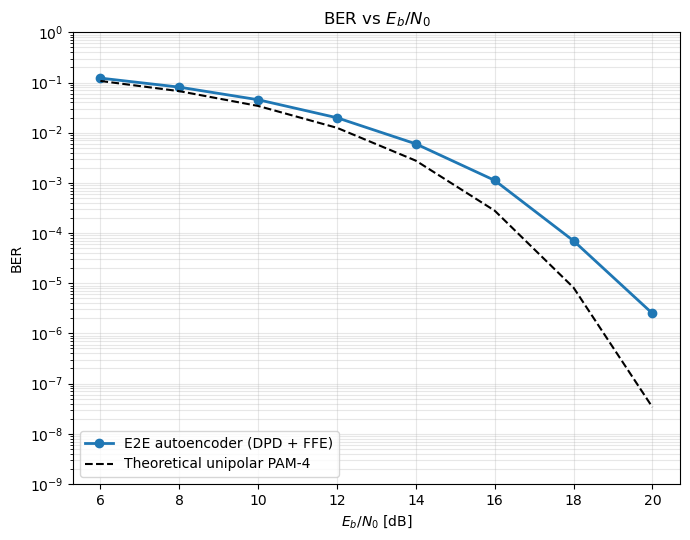

In [4]:
theory = theoretical_ber_unipolar(ebn0_db, config.modulation_order)
measured_floor = np.maximum(measured, 1.0 / NUM_EVAL)   # smallest resolvable BER

print("  Eb/N0     measured     theory")
for e, m, t in zip(ebn0_db, measured, theory):
    print(f"  {e:5.1f}    {m:.3e}    {t:.3e}")

fig_ber, ax_ber = plt.subplots(figsize=(7, 5.5))
ax_ber.semilogy(ebn0_db, measured_floor, "-o", linewidth=2, label="E2E autoencoder (DPD + FFE)")
ax_ber.semilogy(ebn0_db, theory, "k--", linewidth=1.5, label="Theoretical unipolar PAM-4")
ax_ber.grid(True, which="both", alpha=0.3)
ax_ber.set_xlabel(r"$E_b/N_0$ [dB]")
ax_ber.set_ylabel("BER")
ax_ber.set_ylim(1e-9, 1)
ax_ber.set_title("BER vs $E_b/N_0$")
ax_ber.legend(loc="lower left")
fig_ber.tight_layout()
fig_ber.savefig(os.path.join("results", "pam4_ber.png"), dpi=150, bbox_inches="tight")
plt.show()